# Synthetic "hard" validation scenes for cell tracking

This notebook builds a **local validation set** (`test_hard/`) of `.zarr` + `.geff` pairs in exactly the same format as `train/`, but deliberately harder and more varied: denser cell populations, more (and synchronized) divisions, close encounters between unrelated lineages, dim/low-contrast cells, and faster motion. It exists so you can score your own tracker against **known, exhaustive ground truth** with `metrics.py` before ever touching the real held-out test set.

**Approach.** Real zebrafish nuclear-label frames are already wall-to-wall packed with cells (see the visual check right below) -- reproducing that texture from scratch would need a much heavier tissue simulator than is worth building here. Instead, this notebook:

1. Takes a **real image volume** from `train/` as the background (real noise, real optics, real distractor cells).
2. Cuts small **real nucleus templates** from patches centered on real, GT-confirmed centroids in that same sample, so every template is a genuine, well-formed nucleus.
3. Simulates new **lineages** (random-walk motion + mitosis) entirely in voxel space, and paints each simulated cell into the volume every frame by pasting a template, feathered so there is no visible seam.
4. Exports the *exact* simulated trajectories as ground truth -- perfect by construction, no manual annotation involved.

**Annotation density.** Real `train/*.geff` files annotate a hand-picked handful of lineages against a much larger visible population (e.g. one sample has 52 GT nodes against an `estimated_number_of_nodes` of ~25755). This notebook mirrors that structurally: every generated scene simulates a number of full lineages, and only a *configurable fraction* (`annotate_frac`) is exported to `.geff` -- the rest render into the volume as unannotated distractors, exactly like the real dense background population. Setting `annotate_frac=1.0` instead gives full, dense ground truth for every simulated cell, which is usually what you want for a *validation* set since it removes the sparse-annotation noise floor from your local metric -- so most presets below lean toward the high end, with one preset deliberately mimicking the sparse style for comparison.

In [1]:
from __future__ import annotations

import shutil
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import geff
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import zarr
from tqdm.auto import tqdm
from zarr.codecs import BloscCodec, BytesCodec

import metrics

TRAIN_DIR = Path("train")
OUT_DIR = Path("test_hard")
OUT_DIR.mkdir(exist_ok=True)

SCALE_ZYX = np.array([1.625, 0.40625, 0.40625])  # z, y, x um/voxel -- from the dataset spec
PATCH_SHAPE = (11, 25, 25)  # z, y, x voxels: covers one real nucleus plus a feather margin

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Why hybrid real+synthetic

A quick look at one real sample makes the case directly: nuclei fill essentially the whole frame, and the GT graph annotates only a handful of them.

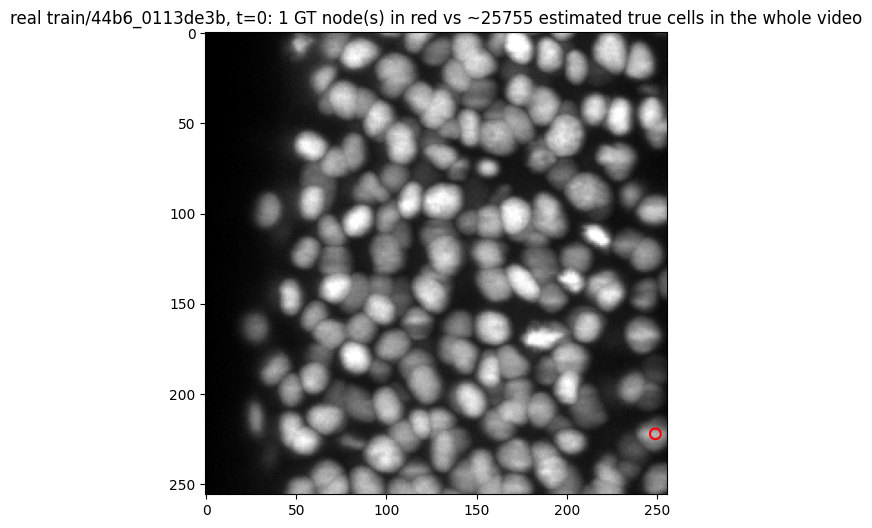

In [2]:
_demo_arr = zarr.open(TRAIN_DIR / "44b6_0113de3b.zarr", mode="r")["0"]
_demo_g, _demo_meta = geff.read(TRAIN_DIR / "44b6_0113de3b.geff")
_demo_mip = _demo_arr[0].max(axis=0).astype(np.float32)
_demo_pts = [(d["y"], d["x"]) for _, d in _demo_g.nodes(data=True) if d["t"] == 0]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(_demo_mip, cmap="gray", vmin=np.percentile(_demo_mip, 1), vmax=np.percentile(_demo_mip, 99.5))
ax.scatter([p[1] for p in _demo_pts], [p[0] for p in _demo_pts],
           s=60, facecolors="none", edgecolors="red", linewidths=1.5)
ax.set_title(
    f"real train/44b6_0113de3b, t=0: {len(_demo_pts)} GT node(s) in red vs "
    f"~{_demo_meta.extra['estimated_number_of_nodes']} estimated true cells in the whole video"
)
plt.show()

## Real nucleus templates

`build_template_bank` crops small patches centered on real, GT-confirmed centroids (never on an arbitrary bright pixel, so every template is a confirmed, well-formed nucleus). `paste` blends a template into a frame through a Hann window that fades to 0 at the patch border, so the join is invisible however busy the surrounding tissue is.

In [3]:
def load_base(name: str) -> tuple[zarr.Array, np.ndarray, int]:
    """Real image volume + real annotated centroids + the sample's own true-count estimate."""
    arr = zarr.open(TRAIN_DIR / f"{name}.zarr", mode="r")["0"]
    g, meta = geff.read(TRAIN_DIR / f"{name}.geff")
    centroids = np.array([(d["t"], d["z"], d["y"], d["x"]) for _, d in g.nodes(data=True)])
    estimated_n = int(meta.extra.get("estimated_number_of_nodes", 0))
    return arr, centroids, estimated_n


def make_window(shape: tuple[int, int, int]) -> np.ndarray:
    """Separable Hann window: 1.0 at the patch center, fading to 0 at its edges."""
    axes = [np.hanning(s + 2)[1:-1] if s > 1 else np.ones(1) for s in shape]
    return (axes[0][:, None, None] * axes[1][None, :, None] * axes[2][None, None, :]).astype(np.float32)


def build_template_bank(arr: zarr.Array, centroids: np.ndarray, rng: np.random.Generator,
                         n_templates: int, patch_shape: tuple[int, int, int]) -> list[np.ndarray]:
    """Crop real nucleus patches around real GT centroids, background-subtracted."""
    Z, Y, X = arr.shape[1:]
    pz, py, px = patch_shape
    templates = []
    candidates = rng.integers(0, len(centroids), size=n_templates * 4)
    for i in candidates:
        if len(templates) >= n_templates:
            break
        t, z, y, x = centroids[i]
        in_bounds = (pz // 2 <= z < Z - pz // 2 - 1 and py // 2 <= y < Y - py // 2 - 1
                     and px // 2 <= x < X - px // 2 - 1)
        if not in_bounds:
            continue
        frame = arr[int(t)]
        patch = frame[z - pz // 2: z - pz // 2 + pz,
                      y - py // 2: y - py // 2 + py,
                      x - px // 2: x - px // 2 + px].astype(np.float32)
        background = np.percentile(patch, 10)
        templates.append(np.clip(patch - background, 0, None))
    return templates


def paste(frame: np.ndarray, patch: np.ndarray, center: tuple[float, float, float]) -> None:
    """Additively blend `patch` into `frame` at `center`, clipped to the frame bounds."""
    pz, py, px = patch.shape
    Z, Y, X = frame.shape
    cz, cy, cx = (int(round(c)) for c in center)
    z0, y0, x0 = cz - pz // 2, cy - py // 2, cx - px // 2
    z1, y1, x1 = z0 + pz, y0 + py, x0 + px
    fz0, fz1 = max(z0, 0), min(z1, Z)
    fy0, fy1 = max(y0, 0), min(y1, Y)
    fx0, fx1 = max(x0, 0), min(x1, X)
    if fz0 >= fz1 or fy0 >= fy1 or fx0 >= fx1:
        return
    frame[fz0:fz1, fy0:fy1, fx0:fx1] += patch[fz0 - z0:fz1 - z0, fy0 - y0:fy1 - y0, fx0 - x0:fx1 - x0]

## Lineage simulation

Each `HardConfig` describes one scene. `simulate` runs a damped random walk per lineage (motion noise sampled isotropically in real µm, then converted to voxels, since z is ~4x coarser than x/y) and schedules mitosis per track. Checking the real data first matters here: in every training sample with a division, the two children always land at `parent_t + 1`, never at `parent_t` itself -- `simulate` reproduces that exactly (a track born this frame is skipped for one step, not stepped twice).

Three knobs turn "harder" into specific, targeted failure modes rather than just noise:
- `sync_wave` forces a fraction of lineages to divide within a few frames of each other (an early-cleavage-style synchronized burst).
- `n_close_encounters` scripts two *unrelated* lineages (different root, so it's a genuine crossing, not divergence from a shared division) to swing toward a common midpoint for a short window -- a manufactured near-miss.
- `dim_frac` renders a subset of tracks at reduced contrast, stressing detection rather than linking.

`annotate_frac` is applied per-lineage-tree (root + every descendant), never per-node, so every exported connected component is a clean, complete lineage -- matching how the real components are structured.

In [4]:
@dataclass
class HardConfig:
    """One synthetic scene: which real sample to build on top of, and how to stress it."""

    tag: str
    base_sample: str
    n_seeds: int = 15                  # independent lineages (trees) started at t=0
    p_divide: float = 0.3              # probability a given track eventually divides
    min_age: int = 10                  # frames a track must live before it may divide
    max_age: int = 70                  # latest frame (relative to birth) a division may be scheduled
    sync_wave: tuple[float, int, int] | None = None  # (fraction_of_seeds, t0, jitter)
    n_close_encounters: int = 0        # scripted near-misses between two unrelated lineages
    dim_frac: float = 0.0              # fraction of tracks rendered at reduced contrast
    motion_um_sigma: float = 0.35      # per-frame motion noise, in real um (isotropic)
    momentum: float = 0.7              # velocity persistence, 0 = pure random walk
    bright_range: tuple[float, float] = (0.7, 1.3)
    annotate_frac: float = 1.0         # fraction of seed lineages exported to .geff
    n_templates: int = 24
    seed: int = 0


def simulate(shape: tuple[int, int, int, int], rng: np.random.Generator, cfg: HardConfig) -> dict:
    """Random-walk + mitosis simulation for every lineage, in voxel space.

    Returns every track, including lineages never exported to GT: they still get
    rendered, standing in for the dense unannotated population real samples show.
    """
    T, Z, Y, X = shape
    margin = np.array(PATCH_SHAPE) * 0.7
    upper = np.array([Z, Y, X]) - margin
    tracks: dict[int, dict] = {}
    next_id = [0]

    def new_track(pos, vel, parent, birth_t):
        tid = next_id[0]
        next_id[0] += 1
        will_divide = rng.random() < cfg.p_divide
        next_div_t = int(rng.integers(birth_t + cfg.min_age, birth_t + cfg.max_age)) if will_divide else None
        if next_div_t is not None and next_div_t >= T - 1:
            next_div_t = None
        root = tid if parent is None else tracks[parent]["root"]
        tracks[tid] = dict(
            parent=parent, root=root, positions={birth_t: pos.copy()}, vel=vel.copy(),
            template_idx=int(rng.integers(0, cfg.n_templates)),
            brightness_scale=rng.uniform(*cfg.bright_range),
            birth_t=birth_t, last_t=birth_t, next_div_t=next_div_t,
            div_countdown=0, push_dir=np.zeros(3), push_speed=0.0, daughters=[],
        )
        return tid

    for _ in range(cfg.n_seeds):
        new_track(rng.uniform(margin, upper), np.zeros(3), parent=None, birth_t=0)

    if cfg.sync_wave:
        frac, t0, jitter = cfg.sync_wave
        seed_ids = list(tracks.keys())
        chosen = rng.choice(seed_ids, size=max(1, int(len(seed_ids) * frac)), replace=False)
        for tid in chosen:
            tracks[tid]["next_div_t"] = int(np.clip(t0 + rng.integers(-jitter, jitter + 1), cfg.min_age, T - 2))

    active = list(tracks.keys())
    for t in range(1, T):
        still_active = []
        for tid in active:
            tr = tracks[tid]
            if max(tr["positions"]) == t:
                # Born this frame (daughter side of a division at t-1 -> t): its
                # birth position already stands for frame t; resume stepping next frame.
                still_active.append(tid)
                continue

            tr["vel"] = cfg.momentum * tr["vel"] + rng.normal(0, cfg.motion_um_sigma, 3) / SCALE_ZYX
            pos = tr["positions"][t - 1] + tr["vel"]
            if tr["div_countdown"] > 0:
                pos = pos + tr["push_dir"] * tr["push_speed"]
                tr["div_countdown"] -= 1
            for ax in range(3):
                if pos[ax] < margin[ax]:
                    pos[ax] = margin[ax] + (margin[ax] - pos[ax])
                    tr["vel"][ax] *= -1
                elif pos[ax] > upper[ax]:
                    pos[ax] = upper[ax] - (pos[ax] - upper[ax])
                    tr["vel"][ax] *= -1
            tr["positions"][t] = pos
            tr["last_t"] = t

            if tr["next_div_t"] == t and t < T - 1:
                dir_vox = rng.normal(0, 1, 3) / SCALE_ZYX
                dir_vox /= np.linalg.norm(dir_vox) + 1e-9
                push_speed = rng.uniform(0.8, 1.6)
                for sign in (1, -1):
                    did = new_track(pos + sign * dir_vox * 0.5, tr["vel"] * 0.5, parent=tid, birth_t=t + 1)
                    tracks[did].update(div_countdown=4, push_dir=sign * dir_vox, push_speed=push_speed)
                    tr["daughters"].append(did)
                    still_active.append(did)
            else:
                still_active.append(tid)
        active = still_active

    if cfg.dim_frac > 0:
        all_ids = list(tracks.keys())
        chosen = rng.choice(all_ids, size=max(1, int(len(all_ids) * cfg.dim_frac)), replace=False)
        for tid in chosen:
            tracks[tid]["brightness_scale"] *= rng.uniform(0.25, 0.45)

    if cfg.n_close_encounters > 0:
        _inject_close_encounters(tracks, rng, cfg.n_close_encounters)

    return tracks


def _inject_close_encounters(tracks: dict, rng: np.random.Generator, n_events: int) -> None:
    """Pull two unrelated, simultaneously-alive tracks toward a shared midpoint for a
    short window, so their paths genuinely cross instead of just co-existing."""
    ids = [tid for tid, tr in tracks.items() if tr["last_t"] - tr["birth_t"] > 20]
    for _ in range(n_events):
        if len(ids) < 2:
            return
        pairs = [(a, b) for i, a in enumerate(ids) for b in ids[i + 1:] if tracks[a]["root"] != tracks[b]["root"]]
        a, b = pairs[rng.integers(len(pairs))] if pairs else tuple(rng.choice(ids, size=2, replace=False))
        ta, tb = tracks[a], tracks[b]
        lo = max(ta["birth_t"], tb["birth_t"]) + 5
        hi = min(ta["last_t"], tb["last_t"]) - 5
        if hi <= lo:
            continue
        t_mid = int(rng.integers(lo, hi))
        window = 8
        mid_point = (ta["positions"][t_mid] + tb["positions"][t_mid]) / 2
        t_lo = max(ta["birth_t"], tb["birth_t"], t_mid - window)
        t_hi = min(ta["last_t"], tb["last_t"], t_mid + window)
        for t in range(t_lo, t_hi + 1):
            w = max(0.0, 1 - abs(t - t_mid) / window) * 0.85
            ta["positions"][t] = ta["positions"][t] * (1 - w) + mid_point * w
            tb["positions"][t] = tb["positions"][t] * (1 - w) + mid_point * w

In [5]:
def select_annotated(tracks: dict, rng: np.random.Generator, annotate_frac: float) -> set[int]:
    """Pick a subset of whole lineages (root + all descendants) to export as GT."""
    roots = sorted({tr["root"] for tr in tracks.values()})
    n_pick = max(1, round(len(roots) * annotate_frac))
    chosen_roots = set(rng.choice(roots, size=n_pick, replace=False))
    return {tid for tid, tr in tracks.items() if tr["root"] in chosen_roots}


def collect_render_events(tracks: dict) -> dict[int, list[tuple]]:
    """Every track's (z, y, x, template, brightness) at every frame it is alive -- annotated or not."""
    by_t: dict[int, list[tuple]] = {}
    for tr in tracks.values():
        for t, pos in tr["positions"].items():
            by_t.setdefault(t, []).append((*pos, tr["template_idx"], tr["brightness_scale"]))
    return by_t


def build_annotated_graph(tracks: dict, annotated_ids: set[int]) -> nx.DiGraph:
    g = nx.DiGraph()
    node_id_of = {}
    counter = 0
    for tid in annotated_ids:
        for t in sorted(tracks[tid]["positions"]):
            z, y, x = tracks[tid]["positions"][t]
            g.add_node(counter, t=int(t), z=int(round(z)), y=int(round(y)), x=int(round(x)))
            node_id_of[(tid, t)] = counter
            counter += 1
    for tid in annotated_ids:
        tr = tracks[tid]
        ts = sorted(tr["positions"])
        for a, b in zip(ts, ts[1:]):
            g.add_edge(node_id_of[(tid, a)], node_id_of[(tid, b)])
        for did in tr["daughters"]:
            if did in annotated_ids:
                g.add_edge(node_id_of[(tid, tr["last_t"])], node_id_of[(did, tracks[did]["birth_t"])])
    return g

## Writers

`render_and_write_zarr` writes the same array layout as `train/*.zarr` (shape, dtype, per-timepoint chunking, blosc/zstd codec) so it's a drop-in replacement for anything that already reads `train/`. `write_geff` uses the real `geff` library rather than hand-rolling the zarr v3 group structure, so the output is spec-guaranteed compatible; the one thing `geff.write` cannot infer -- `estimated_number_of_nodes`, since most of the true population never becomes a node here either -- is patched onto the metadata afterward exactly like the real files carry it.

In [6]:
def render_and_write_zarr(path: Path, shape: tuple[int, int, int, int], base_arr: zarr.Array,
                           templates: list[np.ndarray], window: np.ndarray,
                           render_events: dict[int, list[tuple]]) -> None:
    T, Z, Y, X = shape
    root = zarr.open_group(path, mode="w", zarr_format=3)
    arr = zarr.create_array(
        root.store, name="0", shape=shape, dtype=np.uint16,
        chunks=(1, Z, Y, X),
        compressors=[BloscCodec(typesize=2, cname="zstd", clevel=1, shuffle="bitshuffle", blocksize=0)],
        filters=[], serializer=BytesCodec(endian="little"), fill_value=0, zarr_format=3,
    )
    for t in range(T):
        frame = base_arr[t].astype(np.float32)
        for z, y, x, tidx, bscale in render_events.get(t, []):
            paste(frame, templates[tidx] * window * bscale, (z, y, x))
        arr[t] = np.clip(frame, 0, 65535).astype(np.uint16)

    root.attrs.put({
        "multiscales": [{
            "version": "0.5",
            "axes": [
                {"name": "T", "type": "time", "unit": "second"},
                {"name": "Z", "type": "space", "unit": "micrometer"},
                {"name": "Y", "type": "space", "unit": "micrometer"},
                {"name": "X", "type": "space", "unit": "micrometer"},
            ],
            "datasets": [{"path": "0", "coordinateTransformations": [
                {"type": "scale", "scale": [1.0, *SCALE_ZYX.tolist()]},
            ]}],
            "name": "0",
        }],
    })


def write_geff(path: Path, g: nx.DiGraph, estimated_number_of_nodes: int) -> None:
    geff.write(g, path, axis_names=["t", "z", "y", "x"],
               axis_types=["time", "space", "space", "space"],
               axis_scales=[1.0, *SCALE_ZYX.tolist()],
               zarr_format=3, overwrite=True)
    grp = zarr.open_group(path, mode="a")
    attrs = dict(grp.attrs)
    geff_attrs = dict(attrs["geff"])
    geff_attrs["extra"] = {"estimated_number_of_nodes": estimated_number_of_nodes}
    attrs["geff"] = geff_attrs
    grp.attrs.put(attrs)


def generate_dataset(cfg: HardConfig, out_dir: Path, T: int = 100) -> dict:
    rng = np.random.default_rng(cfg.seed)
    base_arr, centroids, base_estimated_n = load_base(cfg.base_sample)
    shape = (T, *base_arr.shape[1:])

    templates = build_template_bank(base_arr, centroids, rng, cfg.n_templates, PATCH_SHAPE)
    window = make_window(PATCH_SHAPE)
    cfg.n_templates = len(templates)  # bank may be smaller than requested near volume edges

    tracks = simulate(shape, rng, cfg)
    annotated_ids = select_annotated(tracks, rng, cfg.annotate_frac)
    g = build_annotated_graph(tracks, annotated_ids)
    render_events = collect_render_events(tracks)

    estimated_n = base_estimated_n + sum(len(tr["positions"]) for tr in tracks.values())

    render_and_write_zarr(out_dir / f"{cfg.tag}.zarr", shape, base_arr, templates, window, render_events)
    write_geff(out_dir / f"{cfg.tag}.geff", g, estimated_n)

    return dict(
        tag=cfg.tag, base_sample=cfg.base_sample, T=T,
        n_tracks_total=len(tracks), n_tracks_annotated=len(annotated_ids),
        n_nodes=g.number_of_nodes(), n_edges=g.number_of_edges(),
        n_divisions=sum(1 for n in g.nodes if g.out_degree(n) >= 2),
        estimated_number_of_nodes=estimated_n,
    )

## Smoke test

One small (`T=30`), fast run before committing to the full batch: generates into a throwaway folder, checks the `.geff` round-trips through `metrics.py` with a perfect self-match, plots one frame with GT overlaid, then cleans up.

{'tag': '_smoke_test', 'base_sample': '6bba_05db0fb1', 'T': 30, 'n_tracks_total': 22, 'n_tracks_annotated': 22, 'n_nodes': 428, 'n_edges': 416, 'n_divisions': 5, 'estimated_number_of_nodes': 70228}


self-match edge Jaccard (expect 1.0): 1.0
self-match division Jaccard (expect 1.0): 1.0


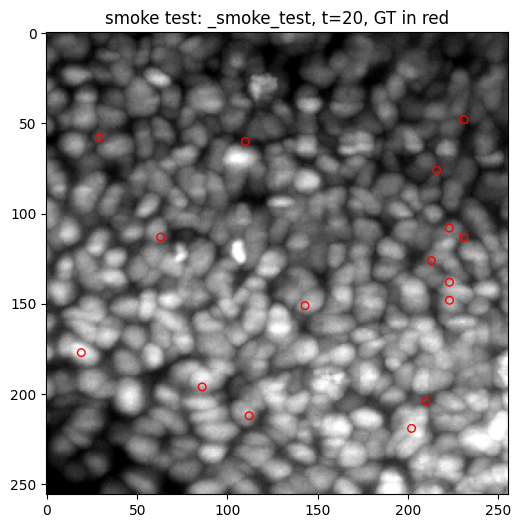

In [7]:
def load_geff_as_trackgraph(path: Path) -> tuple[metrics.TrackGraph, dict]:
    g, meta = geff.read(path)
    ids = list(g.nodes())
    tg = metrics.build_graph(
        ids,
        [g.nodes[n]["t"] for n in ids], [g.nodes[n]["z"] for n in ids],
        [g.nodes[n]["y"] for n in ids], [g.nodes[n]["x"] for n in ids],
        list(g.edges()),
    )
    return tg, meta


_smoke_cfg = HardConfig(tag="_smoke_test", base_sample="6bba_05db0fb1", n_seeds=12,
                         p_divide=0.5, min_age=5, max_age=18, n_close_encounters=2, seed=0)
_smoke_dir = Path("test_hard_smoke")
_smoke_dir.mkdir(exist_ok=True)
_smoke_stats = generate_dataset(_smoke_cfg, _smoke_dir, T=30)
print(_smoke_stats)

_tg, _meta = load_geff_as_trackgraph(_smoke_dir / f"{_smoke_cfg.tag}.geff")
_self_check = metrics.evaluate(_tg, _tg, estimated_true_nodes=_smoke_stats["estimated_number_of_nodes"])
print("self-match edge Jaccard (expect 1.0):", _self_check["edge"]["jaccard"])
print("self-match division Jaccard (expect 1.0):", _self_check["division"]["jaccard"])

_zarr_smoke = zarr.open(_smoke_dir / f"{_smoke_cfg.tag}.zarr", mode="r")["0"]
_t_show = 20
_mip = _zarr_smoke[_t_show].max(axis=0).astype(np.float32)
_pts = [(d["y"], d["x"]) for _, d in geff.read(_smoke_dir / f"{_smoke_cfg.tag}.geff")[0].nodes(data=True) if d["t"] == _t_show]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(_mip, cmap="gray", vmin=np.percentile(_mip, 1), vmax=np.percentile(_mip, 99.5))
if _pts:
    ax.scatter([p[1] for p in _pts], [p[0] for p in _pts], s=30, facecolors="none", edgecolors="red")
ax.set_title(f"smoke test: {_smoke_cfg.tag}, t={_t_show}, GT in red")
plt.show()

shutil.rmtree(_smoke_dir)

## Ten preset scenes

Each targets a specific failure mode, cycling through all four real training samples as backgrounds so the visual style varies too:

| tag | stress axis | base |
|---|---|---|
| hard01_gentle_b1 | mild step up from train (baseline sanity check) | 44b6_0113de3b |
| hard02_gentle_b2 | mild + one scripted close encounter | 44b6_0b24845f |
| hard03_crowded_b3 | high cell density, most of it annotated | 6bba_05b6850b |
| hard04_crowded_fast_b4 | dense + faster motion (linking/gating stress) | 6bba_05db0fb1 |
| hard05_division_wave_b1 | synchronized division burst (cleavage-wave style) | 44b6_0113de3b |
| hard06_division_wave_b4 | division burst + crossing lineages | 6bba_05db0fb1 |
| hard07_fast_motion_b2 | large frame-to-frame displacement | 44b6_0b24845f |
| hard08_low_snr_b3 | half the annotated cells rendered dim | 6bba_05b6850b |
| hard09_sparse_style_b1 | many simulated lineages, only 15% annotated (mimics real train sparsity) | 44b6_0113de3b |
| hard10_kitchen_sink_b4 | everything above, at once | 6bba_05db0fb1 |

All ten share the same code path (`generate_dataset`); only the `HardConfig` knobs differ, so it's easy to retune a preset or add more.

In [8]:
BASES = ["44b6_0113de3b", "44b6_0b24845f", "6bba_05b6850b", "6bba_05db0fb1"]

CONFIGS = [
    HardConfig(tag="hard01_gentle_b1", base_sample=BASES[0],
               n_seeds=15, p_divide=0.3, dim_frac=0.1, seed=101),
    HardConfig(tag="hard02_gentle_b2", base_sample=BASES[1],
               n_seeds=15, p_divide=0.3, n_close_encounters=1, seed=102),
    HardConfig(tag="hard03_crowded_b3", base_sample=BASES[2],
               n_seeds=45, p_divide=0.35, annotate_frac=0.9, n_close_encounters=3, seed=103),
    HardConfig(tag="hard04_crowded_fast_b4", base_sample=BASES[3],
               n_seeds=45, p_divide=0.4, annotate_frac=0.85, motion_um_sigma=0.55, seed=104),
    HardConfig(tag="hard05_division_wave_b1", base_sample=BASES[0],
               n_seeds=20, p_divide=0.3, sync_wave=(0.6, 45, 3), seed=105),
    HardConfig(tag="hard06_division_wave_b4", base_sample=BASES[3],
               n_seeds=24, p_divide=0.3, sync_wave=(0.5, 60, 4), n_close_encounters=2, seed=106),
    HardConfig(tag="hard07_fast_motion_b2", base_sample=BASES[1],
               n_seeds=18, p_divide=0.25, motion_um_sigma=0.7, momentum=0.85, seed=107),
    HardConfig(tag="hard08_low_snr_b3", base_sample=BASES[2],
               n_seeds=20, p_divide=0.25, dim_frac=0.5, seed=108),
    HardConfig(tag="hard09_sparse_style_b1", base_sample=BASES[0],
               n_seeds=50, p_divide=0.3, annotate_frac=0.15, seed=109),
    HardConfig(tag="hard10_kitchen_sink_b4", base_sample=BASES[3],
               n_seeds=40, p_divide=0.45, sync_wave=(0.3, 50, 3), n_close_encounters=4,
               dim_frac=0.2, motion_um_sigma=0.6, annotate_frac=0.7, seed=110),
]

## Generate all ten datasets

Each dataset is the same `(100, 64, 256, 256)` uint16 shape as `train/`, compressed with the same blosc/zstd codec (~15-30s and ~300-550 MB apiece here, so a few minutes and a few GB total). Safe to re-run: `generate_dataset` overwrites its own `.zarr`/`.geff` pair and nothing under `train/`.

In [9]:
manifest_rows = []
for cfg in tqdm(CONFIGS, desc="generating test_hard datasets"):
    t0 = time.time()
    stats = generate_dataset(cfg, OUT_DIR, T=100)
    stats["seconds"] = round(time.time() - t0, 1)
    stats.update({f"cfg_{k}": v for k, v in asdict(cfg).items() if k not in ("tag", "base_sample")})
    manifest_rows.append(stats)
    print(f"{stats['tag']:26s} nodes={stats['n_nodes']:5d}  divisions={stats['n_divisions']:3d}  "
          f"annotated/total tracks={stats['n_tracks_annotated']}/{stats['n_tracks_total']}  "
          f"[{stats['seconds']}s]")

generating test_hard datasets:   0%|          | 0/10 [00:00<?, ?it/s]

generating test_hard datasets:  10%|█         | 1/10 [00:13<02:02, 13.64s/it]

hard01_gentle_b1           nodes= 1743  divisions=  6  annotated/total tracks=27/27  [13.6s]


generating test_hard datasets:  20%|██        | 2/10 [00:27<01:50, 13.86s/it]

hard02_gentle_b2           nodes= 1735  divisions=  6  annotated/total tracks=27/27  [14.0s]


...

generating test_hard datasets:  90%|█████████ | 9/10 [02:08<00:14, 14.41s/it]

hard09_sparse_style_b1     nodes=  926  divisions=  4  annotated/total tracks=16/96  [14.7s]


generating test_hard datasets: 100%|██████████| 10/10 [02:23<00:00, 14.41s/it]

generating test_hard datasets: 100%|██████████| 10/10 [02:23<00:00, 14.32s/it]

hard10_kitchen_sink_b4     nodes= 4192  divisions= 33  annotated/total tracks=94/132  [14.4s]


In [10]:
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(OUT_DIR / "manifest.csv", index=False)
manifest[["tag", "base_sample", "n_tracks_total", "n_tracks_annotated", "n_nodes", "n_edges",
          "n_divisions", "estimated_number_of_nodes", "seconds"]]

,tag,base_sample,n_tracks_total,n_tracks_annotated,n_nodes,n_edges,n_divisions,estimated_number_of_nodes,seconds
0,hard01_gentle_b1,44b6_0113de3b,27,27,1743,1728,6,27498,13.6
1,hard02_gentle_b2,44b6_0b24845f,27,27,1735,1720,6,34530,14.0
2,hard03_crowded_b3,6bba_05b6850b,91,82,4772,4732,21,11747,14.6
3,hard04_crowded_fast_b4,6bba_05db0fb1,99,76,4615,4577,19,75455,14.3
4,hard05_division_wave_b1,44b6_0113de3b,58,58,2835,2815,19,28590,14.5
5,hard06_division_wave_b4,6bba_05db0fb1,62,62,3069,3045,19,72869,14.4
6,hard07_fast_motion_b2,44b6_0b24845f,32,32,2083,2065,7,34878,14.6
7,hard08_low_snr_b3,6bba_05b6850b,28,28,2225,2205,4,8587,14.0
8,hard09_sparse_style_b1,44b6_0113de3b,96,16,926,918,4,31827,14.7
9,hard10_kitchen_sink_b4,6bba_05db0fb1,132,94,4192,4164,33,75762,14.4


## Structural self-check

This is **not** a tracker benchmark -- it feeds each generated `.geff` graph into `metrics.evaluate` against *itself*, which only confirms the files round-trip correctly (valid geff structure, edges resolve, forks are recognized as divisions). Both Jaccards should read `1.0` for every row. To actually benchmark a tracker: run it on the `.zarr` volumes in `test_hard/`, build a `TrackGraph` from its output the same way `load_geff_as_trackgraph` does, and score it against the matching `.geff` with `metrics.evaluate` / `metrics.aggregate` -- the same functions `submissions/` is scored with.

In [11]:
check_rows = []
for cfg in CONFIGS:
    tg, meta = load_geff_as_trackgraph(OUT_DIR / f"{cfg.tag}.geff")
    result = metrics.evaluate(tg, tg, estimated_true_nodes=meta.extra["estimated_number_of_nodes"])
    check_rows.append(dict(
        tag=cfg.tag,
        edge_jaccard=result["edge"]["jaccard"],
        division_jaccard=result["division"]["jaccard"],
        n_divisions=result["division"]["n_gt_divisions"],
    ))
pd.DataFrame(check_rows)

,tag,edge_jaccard,division_jaccard,n_divisions
0,hard01_gentle_b1,1.0,1.0,6
1,hard02_gentle_b2,1.0,1.0,6
2,hard03_crowded_b3,1.0,1.0,21
3,hard04_crowded_fast_b4,1.0,1.0,19
4,hard05_division_wave_b1,1.0,1.0,19
5,hard06_division_wave_b4,1.0,1.0,19
6,hard07_fast_motion_b2,1.0,1.0,7
7,hard08_low_snr_b3,1.0,1.0,4
8,hard09_sparse_style_b1,1.0,1.0,4
9,hard10_kitchen_sink_b4,1.0,1.0,33


## Visual gallery

First and last frame of every scene (max-intensity projection over Z), GT centroids in red.

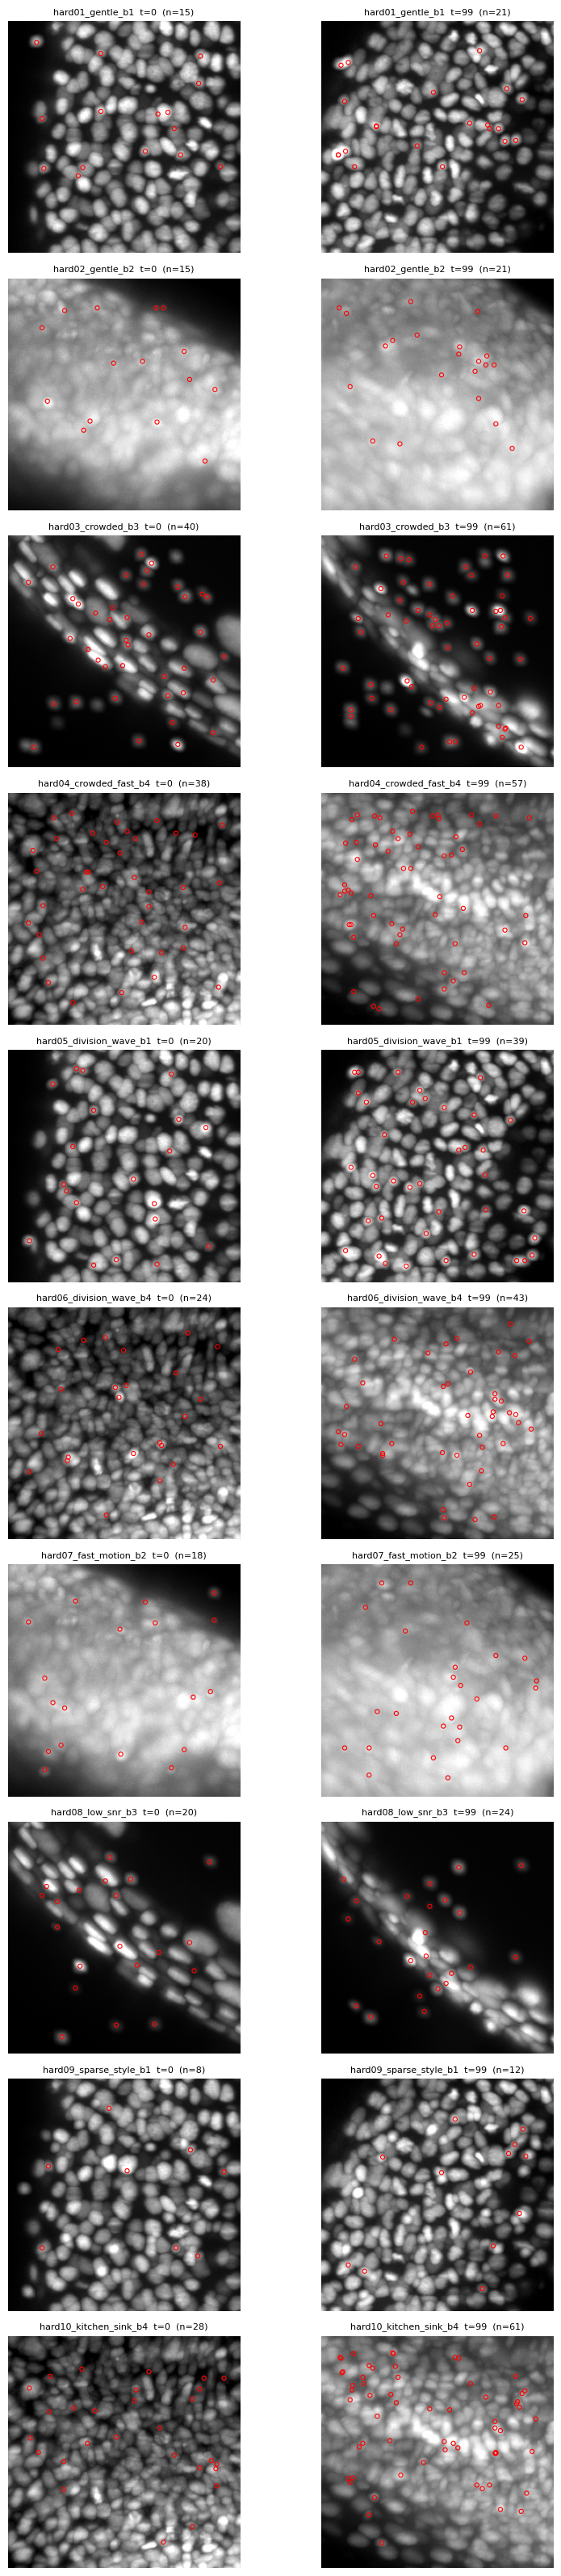

In [12]:
fig, axes = plt.subplots(len(CONFIGS), 2, figsize=(9, 3.2 * len(CONFIGS)))
for row, cfg in enumerate(CONFIGS):
    zarr_arr = zarr.open(OUT_DIR / f"{cfg.tag}.zarr", mode="r")["0"]
    g, _ = geff.read(OUT_DIR / f"{cfg.tag}.geff")
    for col, t_show in enumerate([0, 99]):
        mip = zarr_arr[t_show].max(axis=0).astype(np.float32)
        ax = axes[row, col]
        ax.imshow(mip, cmap="gray", vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99.5))
        pts = [(d["y"], d["x"]) for _, d in g.nodes(data=True) if d["t"] == t_show]
        if pts:
            ax.scatter([p[1] for p in pts], [p[0] for p in pts],
                       s=14, facecolors="none", edgecolors="red", linewidths=0.8)
        ax.set_title(f"{cfg.tag}  t={t_show}  (n={len(pts)})", fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

## Using this for validation going forward

Run your tracker on each `test_hard/*.zarr`, format its output as a `TrackGraph` the same way `load_geff_as_trackgraph` does for the GT, and call `metrics.evaluate(pred, gt, estimated_true_nodes=...)`. `metrics.aggregate` combines per-sample results the same way the leaderboard does, so a `test_hard` score is directly comparable across your own runs -- though not to the public leaderboard number itself, since these scenes are harder by design. `test_hard/manifest.csv` records exactly which knobs produced each file, so a regression can be traced back to a specific stress axis (crowding, divisions, motion, SNR, ...) instead of just "got worse."